
Kernel Size: 3, Sigma: 1.0
Custom Time: 0.52999 sec
OpenCV Time: 0.01976 sec
Mean Difference: 115.16933

Kernel Size: 5, Sigma: 1.5
Custom Time: 0.58361 sec
OpenCV Time: 0.00020 sec
Mean Difference: 124.86637

Kernel Size: 7, Sigma: 2.0
Custom Time: 0.45007 sec
OpenCV Time: 0.00023 sec
Mean Difference: 125.78753


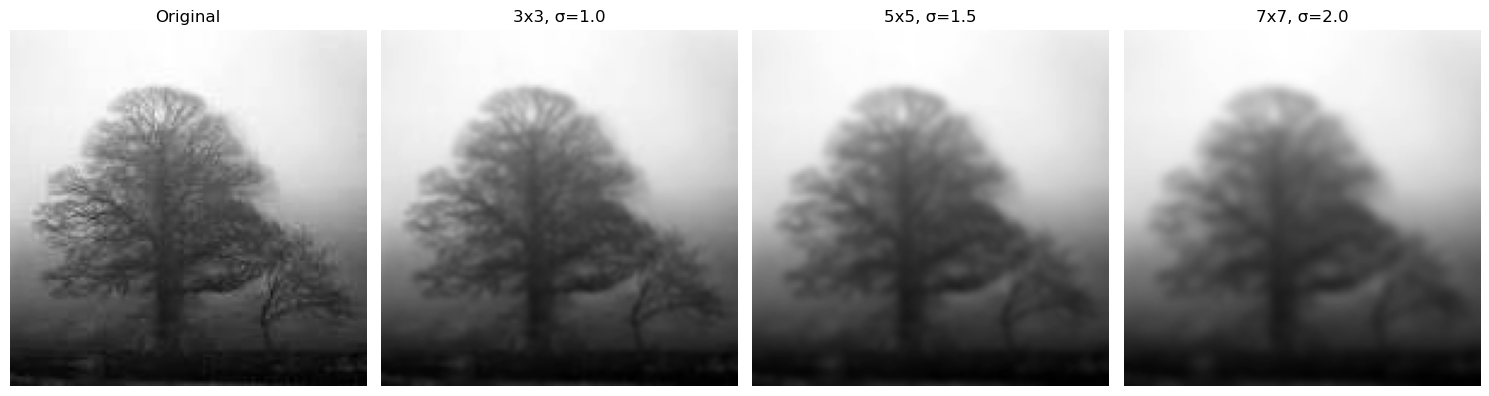

In [1]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

# Load image
img = cv2.imread("image1.jpeg", 0)

if img is None:
    raise ValueError("Image not found.")

# -----------------------------
# Gaussian Kernel Generator
# -----------------------------
def gaussian_kernel(kernel_size, sigma):
    k = kernel_size // 2
    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    
    for x in range(-k, k+1):
        for y in range(-k, k+1):
            kernel[x+k, y+k] = (1 / (2 * np.pi * sigma**2)) * \
                                np.exp(-(x**2 + y**2) / (2 * sigma**2))
    
    # Normalize kernel so sum = 1
    kernel = kernel / np.sum(kernel)
    
    return kernel

# -----------------------------
# Reuse Convolution Function
# -----------------------------
def convolution2D(image, kernel):
    k_h, k_w = kernel.shape
    pad = k_h // 2
    
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='edge')
    output = np.zeros_like(image, dtype=np.float32)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+k_h, j:j+k_w]
            output[i, j] = np.sum(region * kernel)
    
    return np.uint8(output)

# Parameters
params = [(3,1.0), (5,1.5), (7,2.0)]

plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

# Apply Gaussian blur with different parameters
for i, (ksize, sigma) in enumerate(params):
    
    kernel = gaussian_kernel(ksize, sigma)
    
    # Custom Gaussian Blur
    start = time.time()
    custom_blur = convolution2D(img, kernel)
    custom_time = time.time() - start
    
    # OpenCV Gaussian Blur
    start_cv = time.time()
    cv_blur = cv2.GaussianBlur(img, (ksize, ksize), sigma)
    cv_time = time.time() - start_cv
    
    print(f"\nKernel Size: {ksize}, Sigma: {sigma}")
    print(f"Custom Time: {custom_time:.5f} sec")
    print(f"OpenCV Time: {cv_time:.5f} sec")
    print(f"Mean Difference: {np.mean(np.abs(custom_blur - cv_blur)):.5f}")
    
    plt.subplot(1,4,i+2)
    plt.imshow(custom_blur, cmap='gray')
    plt.title(f"{ksize}x{ksize}, σ={sigma}")
    plt.axis('off')

plt.tight_layout()
plt.show()
